<a href="https://colab.research.google.com/github/AxelAllen/Pre-trained-Multimodal-Text-Image-Classifier-in-a-Sparse-Data-Application/blob/master/run_mmbt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Run MMBT Experiments

This notebook shows the end-to-end pipeline for fine-tuning pre-trained MMBT model for multimodal (text and image) classification on our dataset.

Parts of this pipeline are adapted from the
Huggingface `run_mmimdb.py` script to execute the MMBT model. This code can
be accessed [here.](https://github.com/huggingface/transformers/blob/8ea412a86faa8e9edeeb6b5c46b08def06aa03ea/examples/research_projects/mm-imdb/run_mmimdb.py#L305)

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import matplotlib.colors as mcolors
import json
import glob
import rasterio
import torch
import torch.nn.functional as F


ckpt_list = ["ckpt_livability", "ckpt_livability_alphaearth"]
names = ["baseline", "alphearth"]

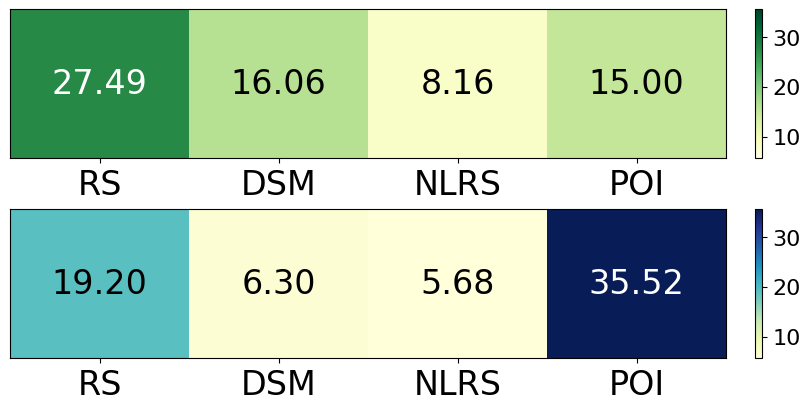

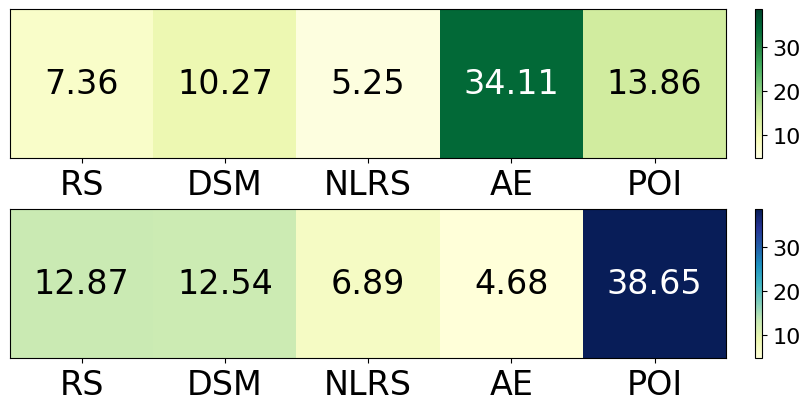

In [2]:
labels = np.load(f"{ckpt_list[0]}/Livability_test_0320_tgts_test_final.npy")

# HIGH_THRESH = 4.4
# LOW_THRESH  = 3.9
# SAMPLE_IDX  = 100

# attn = np.load(f"{ckpt_list[1]}/Livability_test_0320_attentions_test_final.npy")
# np.where((attn[:, -1] < 54) & (labels[:, 0] < LOW_THRESH))

names_arr = [
    ["RS", "DSM", "NLRS", "POI"], 
    ["RS", "DSM", "NLRS", "AE", "POI"]
]


for i, ckpt in enumerate(ckpt_list):
    attn = np.load(f"{ckpt}/Livability_test_0320_attentions_test_final.npy")
    names = names_arr[i]

    # high_label = 10
    # low_label = 8250
    high_label = 7168
    low_label  = 6240


    high_attn = attn[high_label].reshape(1, -1)
    low_attn  = attn[low_label].reshape(1, -1)

    high_score = labels[high_label, 0]
    low_score  = labels[low_label, 0]

    vmin = min(high_attn.min(), low_attn.min())
    vmax = max(high_attn.max(), low_attn.max())

    fig, axes = plt.subplots(2, 1, figsize=(8, 4), constrained_layout=True)

    for ax, data, score, label_type, cmap in [
        (axes[0], high_attn, high_score, "High", "YlGn"),
        (axes[1], low_attn,  low_score,  "Low",  "YlGnBu"),
    ]:
        im = ax.imshow(data, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        for j, val in enumerate(data[0]):
            txt_col = "white" if val > 0.6 * vmax else "black"
            ax.text(j, 0, f"{val:.2f}", ha="center", va="center",
                    fontsize=24, color=txt_col)
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, fontsize=24)
        ax.set_yticks([])
        # ax.set_yticklabels([""], fontsize=9)
        # ax.set_ylabel("Attentions", fontsize=9)
        # ax.set_xlabel("Modalities", fontsize=9)
        # ax.set_title(
        #     f"Attentions on different modalities, "
        #     f"(Livability score: {score:.3f})",
        #     fontsize=10, pad=6
        # )
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=16)

    # fig.suptitle(os.path.basename(ckpt), fontsize=12)
    fig.savefig(f"figs/{ckpt}_attention_heatmap.pdf", dpi=150, bbox_inches="tight")
    plt.show()

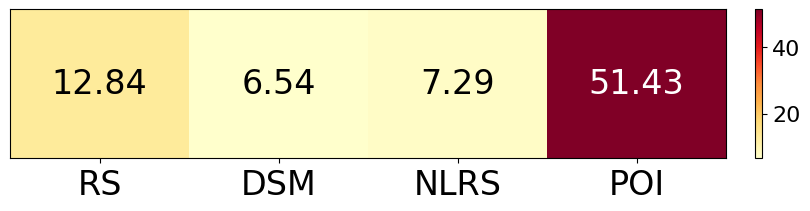

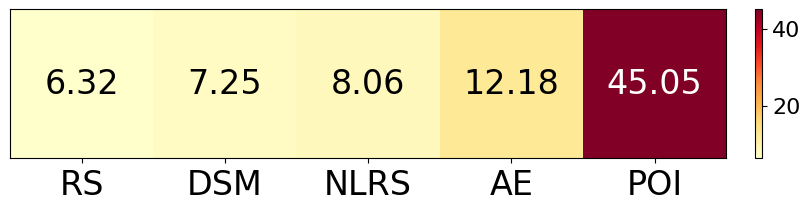

In [7]:
names_arr = [
    ["RS", "DSM", "NLRS", "POI"],
    ["RS", "DSM", "NLRS", "AE", "POI"]
]

for i, ckpt in enumerate(ckpt_list):
    attn = np.load(f"{ckpt}/Livability_test_0320_attentions_test_final.npy")
    names = names_arr[i]

    avg_attn = attn.mean(axis=0).reshape(1, -1)

    vmin = avg_attn.min()
    vmax = avg_attn.max()

    fig, ax = plt.subplots(1, 1, figsize=(8, 2), constrained_layout=True)

    im = ax.imshow(avg_attn, aspect="auto", cmap="YlOrRd", vmin=vmin, vmax=vmax)
    for j, val in enumerate(avg_attn[0]):
        txt_col = "white" if val > 0.6 * vmax else "black"
        ax.text(j, 0, f"{val:.2f}", ha="center", va="center", fontsize=24, color=txt_col)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, fontsize=24)
    ax.set_yticks([])
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=16)

    fig.savefig(f"figs/{ckpt}_attention_heatmap_avg.pdf", dpi=150, bbox_inches="tight")
    plt.show()

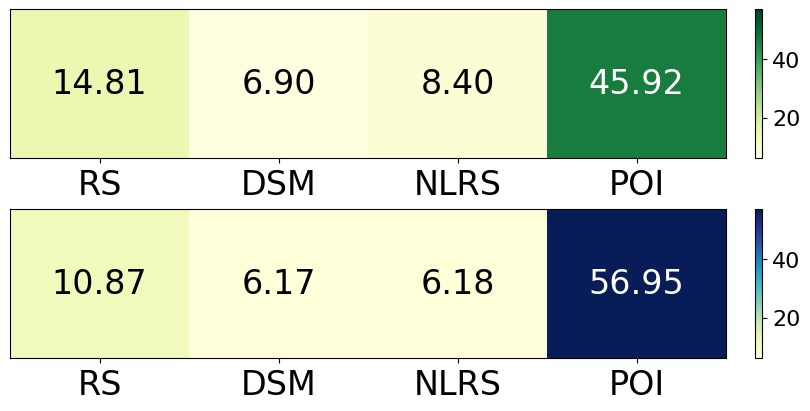

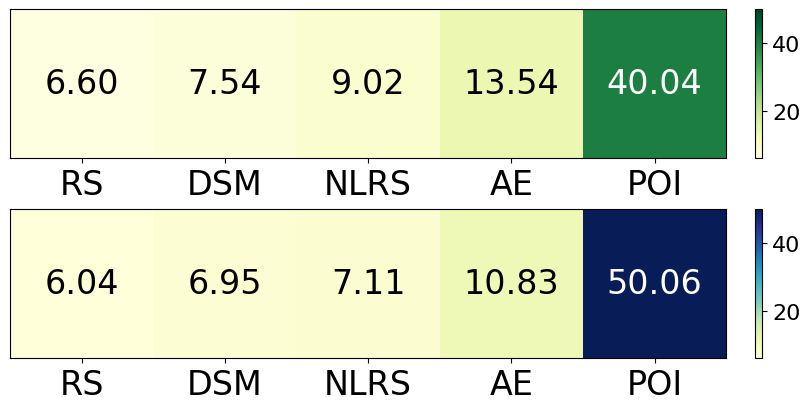

In [6]:
labels = np.load(f"{ckpt_list[0]}/Livability_test_0320_tgts_test_final.npy")
liv = labels[:, 0]

median = np.median(liv)
high_mask = liv >= median
low_mask  = liv <  median

names_arr = [
    ["RS", "DSM", "NLRS", "POI"],
    ["RS", "DSM", "NLRS", "AE", "POI"],
]

for i, ckpt in enumerate(ckpt_list):
    attn = np.load(f"{ckpt}/Livability_test_0320_attentions_test_final.npy")
    names = names_arr[i]

    high_attn = attn[high_mask].mean(axis=0).reshape(1, -1)
    low_attn  = attn[low_mask].mean(axis=0).reshape(1, -1)

    vmin = min(high_attn.min(), low_attn.min())
    vmax = max(high_attn.max(), low_attn.max())

    fig, axes = plt.subplots(2, 1, figsize=(8, 4), constrained_layout=True)

    for ax, data, cmap in [
        (axes[0], high_attn, "YlGn"),
        (axes[1], low_attn,  "YlGnBu"),
    ]:
        im = ax.imshow(data, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        for j, val in enumerate(data[0]):
            txt_col = "white" if val > 0.6 * vmax else "black"
            ax.text(j, 0, f"{val:.2f}", ha="center", va="center",
                    fontsize=24, color=txt_col)
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, fontsize=24)
        ax.set_yticks([])
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=16)

    fig.savefig(f"figs/{ckpt}_attention_heatmap_group.pdf", dpi=150, bbox_inches="tight")
    plt.show()


In [3]:
gdf = gpd.read_file("shpfiles/0217_grids_joint_2_withlbm_test_prediction_4m.shp")

In [4]:
i = 1
coords = [json.loads(line)['img'].split('_')[1].split('.')[0] for line in open(f"data_livability/json/Livability_test_0320.json")]

labels = np.load(f"{ckpt_list[i]}/Livability_test_0320_tgts_test_final.npy")
value_map = {name: val for name, val in zip(coords, labels[:, 0])}
gdf['lbm_gt'] = gdf['grid_id'].map(value_map)

preds = np.load(f"{ckpt_list[i]}/Livability_test_0320_preds_test_final.npy")
value_map = {name: val for name, val in zip(coords, preds[:, 0])}
gdf['lbm_pred'] = gdf['grid_id'].map(value_map)

dif = (preds - labels)
value_map = {name: val for name, val in zip(coords, dif[:, 0])}
gdf['lbm_dif'] = gdf['grid_id'].map(value_map)

preds_0 = np.load(f"{ckpt_list[0]}/Livability_test_0320_preds_test_final.npy")

value_map = {name: val for name, val in zip(coords, preds_0[:, 0])}
gdf['lbm_base_pred'] = gdf['grid_id'].map(value_map)

dif = preds_0 - labels
value_map = {name: val for name, val in zip(coords, dif[:, 0])}
gdf['lbm_base_dif'] = gdf['grid_id'].map(value_map)

dif = abs(preds - labels) - abs(preds_0 - labels)
value_map = {name: val for name, val in zip(coords, dif[:, 0])}
gdf['lbm_dif_dif'] = gdf['grid_id'].map(value_map)

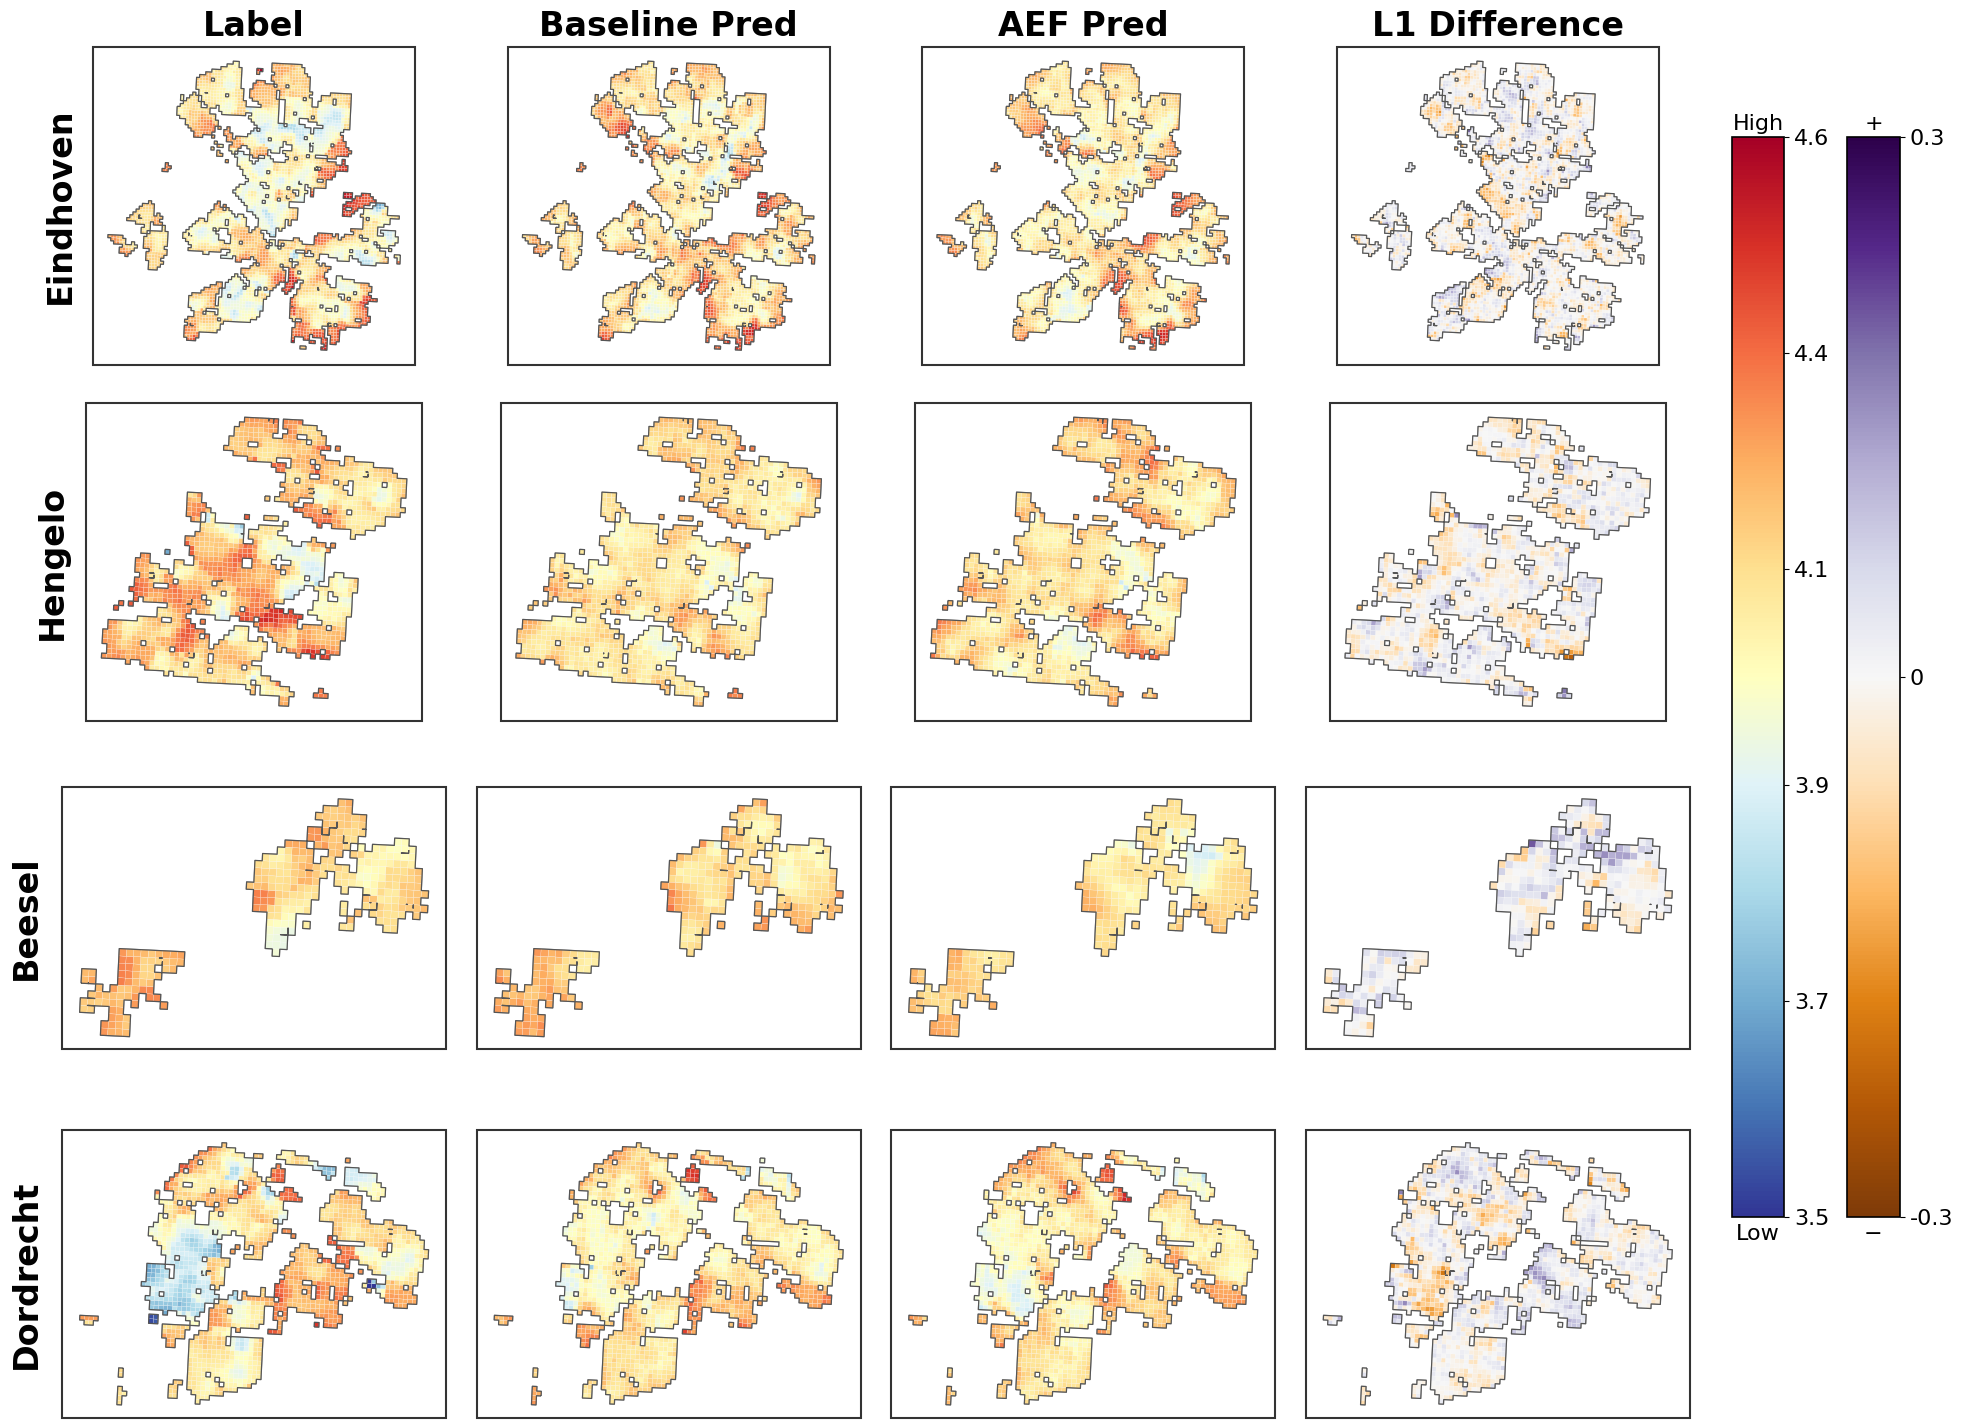

In [6]:
cities   = ['Eindhoven', 'Hengelo', 'Beesel', 'Dordrecht']
col_gt      = 'lbm_gt'
col_base_pred = 'lbm_base_pred'
col_pred    = 'lbm_pred'
col_dif     = 'lbm_dif'
col_dif_dif = 'lbm_dif_dif'
col_base    = 'lbm_base_dif'

vmin    = gdf[[col_gt, col_base_pred, col_pred]].min().min()
vmax    = gdf[[col_gt, col_base_pred, col_pred]].max().max()

# AE diff and baseline diff share the same scale
dif_shared_abs  = max(gdf[col_dif].abs().max(), gdf[col_base].abs().max())  # ← shared max
dif_dif_abs     = gdf[col_dif_dif].abs().max()

cmap_main       = 'RdYlBu_r'
cmap_diff       = 'RdYlGn'        # ← shared cmap for AE diff + baseline diff
cmap_diff_base  = 'PuOr'

norm_main       = mcolors.Normalize(vmin=vmin, vmax=vmax)
norm_diff       = mcolors.TwoSlopeNorm(vmin=-dif_shared_abs, vcenter=0, vmax=dif_shared_abs)  # ← shared norm
norm_diff_dif   = mcolors.TwoSlopeNorm(vmin=-dif_dif_abs,   vcenter=0, vmax=dif_dif_abs)

fig, axes = plt.subplots(
    len(cities), 4,
    figsize=(21, 4.5 * len(cities)),
    gridspec_kw={'wspace': 0.08, 'hspace': 0.12},
    squeeze=False,
)

col_configs = [
    (col_gt,      norm_main,    cmap_main),
    (col_base_pred,    norm_main,    cmap_main),
    (col_pred,    norm_main,    cmap_main),
    # (col_dif,     norm_diff,    cmap_diff),     # ← AE diff
    # (col_base,    norm_diff,    cmap_diff),     # ← baseline diff, same norm+cmap
    (col_dif_dif, norm_diff_dif, cmap_diff_base),
]
# titles = ['Label', 'Baseline Pred', 'AE Pred', 'AE Diff', 'Baseline Diff', 'Abs L1 Diff']
titles = ['Label', 'Baseline Pred', 'AEF Pred', 'L1 Difference']

for row, city in enumerate(cities):
    city_gdf = gdf[gdf['gm_naam'] == city].copy()
    boundary = city_gdf.dissolve()

    for col, (col_name, norm, cmap) in enumerate(col_configs):
        ax = axes[row, col]

        boundary.plot(ax=ax, facecolor='#f0f0f0', edgecolor='#999999', linewidth=0.8)
        city_gdf.plot(column=col_name, ax=ax, cmap=cmap, norm=norm,
                      edgecolor='white', linewidth=0.15, legend=False)
        boundary.plot(ax=ax, facecolor='none', edgecolor='#555555', linewidth=0.9)

        if row == 0:
            ax.set_title(titles[col], fontsize=24, fontweight='bold', pad=8)

        
        ax.axis('off')
        from matplotlib.patches import FancyBboxPatch
        border = FancyBboxPatch((0, 0), 1, 1,
                                boxstyle="square,pad=0",
                                transform=ax.transAxes,
                                linewidth=1.5,
                                edgecolor='#333333',
                                facecolor='none',
                                clip_on=False,
                                zorder=10)
        ax.add_patch(border)

        # ── City label on the leftmost column ────────────────────────────────
        if col == 0:
            ax.text(-0.05, 0.5, city,
                    transform=ax.transAxes,
                    fontsize=24, fontweight='bold',
                    va='center', ha='right',
                    rotation=90)

        # ax.text(0.01, 0.01, f"Legend\n□ {city}", transform=ax.transAxes, fontsize=7,
        #         verticalalignment='bottom',
        #         bbox=dict(boxstyle='square,pad=0.4', facecolor='white',
        #                   edgecolor='black', linewidth=0.7))

# ── Colorbar: GT + Prediction ─────────────────────────────────────────────────
sm_main = plt.cm.ScalarMappable(cmap=cmap_main, norm=norm_main)
cbar_ax1 = fig.add_axes([0.92, 0.23, 0.025, 0.60])
cbar1 = fig.colorbar(sm_main, cax=cbar_ax1)
cbar1.set_ticks(np.linspace(vmin, vmax, 6))
cbar1.set_ticklabels([f"{v:.1f}" for v in np.linspace(vmin, vmax, 6)], fontsize=16)
cbar1.ax.set_title('High', fontsize=16, pad=5)
cbar1.ax.set_xlabel('Low', fontsize=16, labelpad=5)
cbar1.outline.set_linewidth(1.2)

# ── Colorbar: AE Diff + Baseline Diff (shared) ───────────────────────────────
# sm_diff = plt.cm.ScalarMappable(cmap=cmap_diff, norm=norm_diff)
# cbar_ax2 = fig.add_axes([0.952, 0.35, 0.012, 0.35])   # ← close to cbar1
# cbar2 = fig.colorbar(sm_diff, cax=cbar_ax2)
# cbar2.set_ticks([-dif_shared_abs, 0, dif_shared_abs])
# cbar2.set_ticklabels([f"{-dif_shared_abs:.1f}", "0", f"{dif_shared_abs:.1f}"], fontsize=8)
# cbar2.ax.set_title('+', fontsize=8, pad=5)
# cbar2.ax.set_xlabel('−', fontsize=8, labelpad=5)
# cbar2.outline.set_linewidth(0.8)

# ── Colorbar: Prediction Difference ──────────────────────────────────────────
sm_diff_dif = plt.cm.ScalarMappable(cmap=cmap_diff_base, norm=norm_diff_dif)
cbar_ax3 = fig.add_axes([0.975, 0.23, 0.025, 0.60])   # ← further away
cbar3 = fig.colorbar(sm_diff_dif, cax=cbar_ax3)
cbar3.set_ticks([-dif_dif_abs, 0, dif_dif_abs])
cbar3.set_ticklabels([f"{-dif_dif_abs:.1f}", "0", f"{dif_dif_abs:.1f}"], fontsize=16)
cbar3.ax.set_title('+', fontsize=16, pad=5)
cbar3.ax.set_xlabel('−', fontsize=16, labelpad=5)
cbar3.outline.set_linewidth(1.2)

plt.savefig(f"map_paper.pdf", dpi=200, bbox_inches='tight')
plt.show()

In [2]:
all_coords = [json.loads(line)['img'].split('_')[1].split('.')[0] for line in open(f"data_livability/json/Livability_test_0320.json")]

known_coords = ["E1032N4247", "E1069N4252"]

known_indices = {coord: all_coords.index(coord) for coord in known_coords}
print(known_indices)

{'E1032N4247': 2560, 'E1069N4252': 10714}


In [3]:
all_coords = [json.loads(line)['img'].split('_')[1].split('.')[0] for line in open(f"data_livability/json/Livability_test_0320.json")]

SAMPLE_IDX = 10714
coord = all_coords[SAMPLE_IDX]

DSM = [file for file in glob.glob("data_livability/Liva_DSM/*") if coord in file]
GIU_RGB = [file for file in glob.glob("data_livability/Liva_GIU_RGB/*") if coord in file]
RS = [file for file in glob.glob("data_livability/Liva_RS/*") if coord in file]
AE = [file for file in glob.glob("data_livability/alphaearth/*") if coord in file]

cmap = "jet"

In [5]:

def load_and_preprocess_images(rs_path, dsm_path, rgb_path, ae_path):
    """Load and preprocess each modality exactly as in the visualization code."""
    
    # DSM - grayscale, crop [25:225, 25:225]
    with rasterio.open(dsm_path) as src:
        dsm_data = src.read(1).astype(float)
        if src.nodata is not None:
            dsm_data[dsm_data == src.nodata] = np.nan
    dsm_data = dsm_data[25:225, 25:225]  # (200, 200)

    dsm_data = np.where(dsm_data >= 254, 0, dsm_data)
    dsm_data = np.where(dsm_data == 255, 0, dsm_data)


    # GIU_RGB - center crop 50x50
    with rasterio.open(rgb_path) as src:
        r, g, b = src.read(1).astype(float), src.read(2).astype(float), src.read(3).astype(float)
        rgb = np.stack([r, g, b], axis=-1)
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
    H, W, _ = rgb.shape
    cy, cx = H // 2, W // 2
    giu_img = rgb[cy-25:cy+25, cx-25:cx+25, :]  # (50, 50, 3)

    # RS - RGB or grayscale, full image
    with rasterio.open(rs_path) as src:
        n_bands = src.count
        if n_bands >= 3:
            r, g, b = src.read(1).astype(float), src.read(2).astype(float), src.read(3).astype(float)
            rs_img = np.stack([r, g, b], axis=-1)
            rs_img = (rs_img - rs_img.min()) / (rs_img.max() - rs_img.min())
        else:
            rs_img = src.read(1).astype(float)  # (H, W) grayscale


    # AlphaEarth - center crop 50x50, first 3 bands
    ae = np.load(ae_path)
    key = list(ae.keys())[0]
    ae_data = ae[key]
    ae_hwc = ae_data.transpose(1, 2, 0)
    H, W, C = ae_hwc.shape
    cy, cx = H // 2, W // 2
    ae_crop = ae_hwc[cy-25:cy+25, cx-25:cx+25, :]
    ae_rgb  = ae_crop[:, :, 0:3]
    ae_img  = (ae_rgb - np.nanmin(ae_rgb)) / (np.nanmax(ae_rgb) - np.nanmin(ae_rgb))

    return {
        "RS":         rs_img,    # (H, W, 3) or (H, W)
        "DSM":        dsm_data,  # (200, 200) grayscale
        "NLRS":       giu_img,   # (50, 50, 3)
        "AlphaEarth": ae_img,    # (50, 50, 3)
    }



In [8]:
def plot_gradcam_overlay(original_img, cam, ax_orig, ax_overlay, title, vmin, vmax, ax_cam=None):
    
    is_gray = original_img.ndim == 2

    # Resize cam to match original image size
    orig_h, orig_w = original_img.shape[:2]
    if cam.shape != (orig_h, orig_w):
        cam_tensor = torch.tensor(cam).unsqueeze(0).unsqueeze(0).float()
        cam_resized = F.interpolate(
            cam_tensor, size=(orig_h, orig_w), mode='bilinear', align_corners=False
        ).squeeze().numpy()
    else:
        cam_resized = cam

    title_fontsize = 16
    
    # Original
    if is_gray:
        ax_orig.imshow(original_img, cmap='gray')
    else:
        ax_orig.imshow(original_img)
    ax_orig.set_title(f"{title}", fontsize=title_fontsize, fontweight='bold')
    ax_orig.set_box_aspect(1)  # force square
    ax_orig.axis("off")

    # Optional standalone GradCAM
    if ax_cam is not None:
        ax_cam.imshow(cam_resized, cmap=cmap, vmin=vmin, vmax=vmax)
        ax_cam.set_title(f"GradCAM", fontsize=title_fontsize, fontweight='bold')
        ax_cam.set_box_aspect(1)  # force square
        ax_cam.axis("off")

    # Overlay
    if is_gray:
        rgb_display = np.stack([original_img] * 3, axis=-1)
        rgb_display = (rgb_display - np.nanmin(rgb_display)) / (np.nanmax(rgb_display) - np.nanmin(rgb_display) + 1e-8)
    else:
        rgb_display = original_img

    ax_overlay.imshow(rgb_display)
    im = ax_overlay.imshow(cam_resized, cmap=cmap, alpha=0.5, vmin=vmin, vmax=vmax)
    ax_overlay.set_title(f"{title} + GradCAM", fontsize=title_fontsize, fontweight='bold')
    ax_overlay.set_box_aspect(1)  # force square
    ax_overlay.axis("off")
    
    return im


# ── Main plotting loop ───────────────────────────────────────────────────────
show_gradcam = True  # toggle this

images = load_and_preprocess_images(RS[0], DSM[0], GIU_RGB[0], AE[0])

for ckpt in ckpt_list:
    gradcam_maps = np.load(
        f"{ckpt}/Livability_test_0320_gradcam_last_test_final.npy", allow_pickle=True
    ).item()[SAMPLE_IDX]

    modalities  = [m for m in ["RS", "DSM", "NLRS", "AlphaEarth"] if m in gradcam_maps]
    num_outputs = gradcam_maps[modalities[0]].shape[1]

    n_cols = 3 if show_gradcam else 2  # original | [gradcam] | overlay

    for output_idx in range(num_outputs):
        if output_idx != 0:
            continue

        all_cams_main = [gradcam_maps[m][output_idx] for m in ["RS", "DSM", "NLRS"] if m in gradcam_maps]
        all_cams_ae   = [gradcam_maps["AlphaEarth"][output_idx]] if "AlphaEarth" in gradcam_maps else []

        abs_max_main = max(c.max() for c in all_cams_main)
        vmin_main, vmax_main = -abs_max_main, abs_max_main

        if all_cams_ae:
            abs_max_ae = max(abs(c).max() for c in all_cams_ae)
            vmin_ae, vmax_ae = -abs_max_ae, abs_max_ae

        main_modalities = [m for m in ["RS", "DSM", "NLRS"] if m in gradcam_maps]
        ae_modalities   = ["AlphaEarth"] if "AlphaEarth" in gradcam_maps else []
        n_cols = 3 if show_gradcam else 2
        # n_rows = len(main_modalities) + len(ae_modalities)
        n_rows = len(main_modalities)

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows),
                                gridspec_kw={"hspace": 0.4})
        if n_rows == 1:
            axes = axes[np.newaxis, :]

        # ── RS, DSM, NLRS ────────────────────────────────────────────────────
        for row, modality in enumerate(main_modalities):
            plot_gradcam_overlay(
                original_img=images[modality],
                cam=gradcam_maps[modality][output_idx],
                ax_orig=axes[row, 0],
                ax_overlay=axes[row, -1],
                ax_cam=axes[row, 1] if show_gradcam else None,
                title=modality, vmin=vmin_main, vmax=vmax_main,
            )

        # ── AlphaEarth ───────────────────────────────────────────────────────
        # if ae_modalities:
        #     row = len(main_modalities)
        #     plot_gradcam_overlay(
        #         original_img=images["AlphaEarth"],
        #         cam=gradcam_maps["AlphaEarth"][output_idx],
        #         ax_orig=axes[row, 0],
        #         ax_overlay=axes[row, -1],
        #         ax_cam=axes[row, 1] if show_gradcam else None,
        #         title="AlphaEarth", vmin=vmin_ae, vmax=vmax_ae,
        #     )


        cbar_fontsize = 13
        cbar_ticksize = 11
        # ── Two colorbars side by side at the bottom ─────────────────────────
        if ae_modalities and False:
            # Two colorbars side by side
            cbar_ax1 = fig.add_axes([0.05, 0.04, 0.4, 0.02])
            cb1 = fig.colorbar(
                plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin_main, vmax=vmax_main)),
                cax=cbar_ax1, orientation="horizontal",
                label="GradCAM score (RS/DSM/NLRS)"
            )
            cb1.set_label("GradCAM score (RS/DSM/NLRS)", fontsize=cbar_fontsize)
            cb1.ax.tick_params(labelsize=cbar_ticksize)
            cbar_ax2 = fig.add_axes([0.55, 0.04, 0.4, 0.02])
            cb2 = fig.colorbar(
                plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin_ae, vmax=vmax_ae)),
                cax=cbar_ax2, orientation="horizontal",
                label="GradCAM score (AlphaEarth)"
            )
            cb2.set_label("GradCAM score (AlphaEarth)", fontsize=cbar_fontsize)
            cb2.ax.tick_params(labelsize=cbar_ticksize)
        else:
            # Single colorbar centered
            cbar_ax1 = fig.add_axes([0.25, 0.04, 0.5, 0.02])
            cb1 = fig.colorbar(
                plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin_main, vmax=vmax_main)),
                cax=cbar_ax1, orientation="horizontal",
                label="GradCAM score"
            )
            cb1.set_label("GradCAM score", fontsize=cbar_fontsize)
            cb1.ax.tick_params(labelsize=cbar_ticksize)

        fig.savefig(
            f"figs/gradcam_output{output_idx}_sample{SAMPLE_IDX}_{ckpt}.pdf",
            dpi=150,
            bbox_inches="tight"
        )
        plt.close(fig)

        


/u/akhot2/.local/lib/python3.11/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
